# Data Cleaning with pandas and NumPy

Real-world data is messy. Before you can analyze anything, you have to clean it. In this notebook we take the famous Titanic passenger list, make it even messier on purpose, and then fix every problem step by step. Along the way you will learn the two most important Python packages for data work (**pandas** and **NumPy**) and you will practice **loops**, one of the most useful tools in all of programming.

**What you will learn:**

- Why data cleaning is the biggest part of every data job
- How to load a dataset and inspect it with pandas
- How to write `for` loops that walk over the columns of a table
- How to fix the 6 most common data problems: missing values, duplicates, wrong data types, inconsistent text, impossible values, and bad column names
- How to detect outliers with logical rules and the IQR method
- How to write a reusable data-quality report function you can keep forever

## How to run this notebook

You can run this notebook in two ways:

- **Locally with Jupyter:** open it in Jupyter Notebook, JupyterLab, or VS Code and run the cells from top to bottom.
- **On Google Colab:** upload the notebook (or open it straight from GitHub) and run the cells the same way.

The first code cell is a *setup cell*. It checks that the packages we need are installed and installs any that are missing. On Google Colab most packages are already installed, so it usually does nothing.

You do **not** need any account, API key, or download. The dataset loads directly from a public URL, so all you need is an internet connection. Run every cell in order, from top to bottom.

In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("numpy"); ensure("matplotlib")

## 1. Why data cleaning matters

There is a famous saying in data science: **"80% of the job is cleaning data, 20% is complaining about cleaning data."** It is a joke, but it is close to the truth. Surveys of data professionals consistently show that preparing and cleaning data takes more time than any other task.

Why does it matter so much? Because of a second famous saying: **garbage in, garbage out.** If your data is wrong, every chart, statistic, and model you build from it will also be wrong. A single typo like an age of 999 can silently ruin an average.

**Two definitions before we start:**

- **Dataset:** a collection of data, usually shaped like a table with rows and columns.
- **DataFrame:** the pandas name for a table. Rows are observations (for example, one passenger), columns are variables (for example, age).

### The 6 most common data problems

Almost every messy dataset suffers from some mix of these six problems. This notebook fixes all of them, one section at a time.

| # | Problem | Example | Fixed in section |
|---|---------|---------|------------------|
| 1 | **Bad column names** | `" Age "` with spaces, or `PassengerId` vs `passenger_id` | 4 |
| 2 | **Wrong data types** | ages stored as text like `"unknown"` instead of numbers | 5 |
| 3 | **Missing values** | empty cells, shown as `NaN` in pandas | 6 |
| 4 | **Duplicate rows** | the same passenger appears twice | 7 |
| 5 | **Inconsistent text** | `"male"`, `"Male "`, and `" MALE"` all meaning the same thing | 8 |
| 6 | **Impossible values and outliers** | an age of 999, a fare of -1 | 9 |

One more definition: **NaN** stands for "Not a Number". It is the standard marker pandas uses for a missing value.

## 2. Load the data and take a first look

We will work with the **Titanic passenger list**: one row per passenger of the ship that sank in 1912. It is a classic beginner dataset because it is small, real, and already contains genuine missing values.

First we import our two key packages:

- **pandas** (imported as `pd`): the standard Python package for working with tables. Think of it as Excel inside Python, but far more powerful.
- **NumPy** (imported as `np`): the standard package for fast math on arrays of numbers. pandas is built on top of it.

The function `pd.read_csv()` reads a **CSV file** (Comma-Separated Values, a plain-text table format) and returns a DataFrame. It can read directly from a URL, so we do not need to download anything by hand.

In [2]:
import pandas as pd
import numpy as np

URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)

print("Data loaded.")

Data loaded.


### First inspection: head, tail, sample

Never analyze a dataset you have not looked at. Three quick ways to peek at the rows:

- `df.head()` shows the **first** 5 rows.
- `df.tail()` shows the **last** 5 rows.
- `df.sample()` shows **random** rows. We pass `random_state=42` so the "random" pick is the same every time we run it (that number is called a **seed**; it makes randomness reproducible).

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The first rows look sensible. Also check the **last** rows: real files sometimes end with junk such as totals or half-empty lines.

In [4]:
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Head and tail can both look clean while the middle is a mess, so finish with a **random sample**. The fixed seed (42) makes everyone's "random" pick identical.

In [5]:
df.sample(3, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S


### Shape, info, and dtypes

- `df.shape` gives the size as `(rows, columns)`.
- `df.info()` gives a compact overview: every column, how many non-missing values it has, and its data type.
- A **data type** (or **dtype**) tells pandas what kind of values a column holds: `int64` (whole numbers), `float64` (decimal numbers), or `object` / `str` (text).

Look at the `Non-Null Count` column in the output below: `Age`, `Cabin`, and `Embarked` have fewer values than the 891 rows. Those are real missing values that shipped with this dataset.

In [6]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Quick statistics with describe

`df.describe()` computes summary statistics for every numeric column: count, mean, standard deviation, min, quartiles, and max. It is a great way to spot suspicious values early. For example, check that `min` and `max` of each column look believable.

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Loop basics: our most important programming tool

Before we go further, let's learn the **for loop**. A loop repeats a block of code once for every item in a collection. The syntax is:

```python
for item in collection:
    # do something with item  (note the 4-space indentation!)
```

Three variations you will use constantly:

1. `for i in range(5):` loops over the numbers 0, 1, 2, 3, 4. `range(n)` generates numbers from 0 up to (but not including) n.
2. `for i, item in enumerate(collection):` gives you the item **and** its position number at the same time.
3. `for col in df.columns:` loops over the **column names** of a DataFrame. This is the pattern data people use every day.

Let's try each one on tiny examples.

In [8]:
# Variation 1: range - repeat something n times
for i in range(3):
    print("Loop round number", i)

# Variation 2: enumerate - get position AND value
fruits = ["apple", "banana", "cherry"]
for position, fruit in enumerate(fruits):
    print(position, fruit)

# Variation 3: loop over the columns of our DataFrame
for col in df.columns:
    print(col)

Loop round number 0
Loop round number 1
Loop round number 2
0 apple
1 banana
2 cherry
PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked


### Putting the loop to work: a missing-values report

Now we combine the loop with three pandas tools:

- `df[col]` selects one column.
- `.isna()` returns True/False for every cell: True means the value is missing (NaN).
- `.sum()` counts the Trues (True counts as 1, False as 0).

For every column we print the number of missing values, the percentage, and the dtype. This little loop is your first real data-cleaning tool. `len(df)` gives the number of rows, and the `f"..."` syntax is an **f-string**: it lets us insert values into text with `{}` placeholders.

In [9]:
print(f"{'column':<12} {'missing':>8} {'percent':>8}   dtype")
print("-" * 45)
for col in df.columns:
    missing = df[col].isna().sum()
    percent = 100 * missing / len(df)
    print(f"{col:<12} {missing:>8} {percent:>7.1f}%   {df[col].dtype}")

column        missing  percent   dtype
---------------------------------------------
PassengerId         0     0.0%   int64
Survived            0     0.0%   int64
Pclass              0     0.0%   int64
Name                0     0.0%   str
Sex                 0     0.0%   str
Age               177    19.9%   float64
SibSp               0     0.0%   int64
Parch               0     0.0%   int64
Ticket              0     0.0%   str
Fare                0     0.0%   float64
Cabin             687    77.1%   str
Embarked            2     0.2%   str


Read the report: `Cabin` is missing in 77% of rows, `Age` in about 20%, `Embarked` in just 2 rows. We will deal with each one differently later.

## 3. Making the data realistically messy (on purpose)

Honesty time: the Titanic dataset is already a bit messy (real missing values), but it is *too clean* to practice everything on. Real company data also has duplicates, typos, and impossible values.

So we will **inject** a few extra problems ourselves, with a fixed seed (42) so everyone gets the exact same mess:

- 5 duplicate rows
- inconsistent text in `Sex` (`"Male "`, `" MALE"`, ...) and `Embarked` (`" s"`, `"c "`, ...)
- some `Age` values replaced by the text `"unknown"` (which forces the whole column to become text)
- impossible values: three ages of 999 and three fares of -1
- spaces around two column names

We show the injection code openly. It is great practice in *modifying* DataFrames, which is the flip side of cleaning them. Two tools to note:

- `df.copy()` makes an independent copy, so our original `df` stays safe for comparison later.
- `.loc[rows, column]` is the standard way to **select or overwrite** specific cells. Rule of thumb: when changing values, always go through `.loc`.

In [10]:
rng = np.random.default_rng(42)   # NumPy random generator with seed 42
messy = df.copy()

# --- Problem 1: Age becomes text ---------------------------------
# We first convert the column to 'object' (generic) dtype so it can
# hold BOTH numbers and text, then overwrite 15 random ages.
messy["Age"] = messy["Age"].astype(object)
rows_with_age = messy.index[messy["Age"].notna()]
unknown_rows = rng.choice(rows_with_age, size=15, replace=False)
messy.loc[unknown_rows, "Age"] = "unknown"

# --- Problem 2: impossible values --------------------------------
other_rows = [r for r in rows_with_age if r not in unknown_rows]
bad_age_rows = rng.choice(other_rows, size=3, replace=False)
messy.loc[bad_age_rows, "Age"] = 999.0
bad_fare_rows = rng.choice(messy.index, size=3, replace=False)
messy.loc[bad_fare_rows, "Fare"] = -1.0

# --- Problem 3: inconsistent text --------------------------------
messy_sex = ["Male ", " MALE", "Female", " female "]
sex_rows = rng.choice(messy.index, size=12, replace=False)
for i, row in enumerate(sex_rows):
    if messy.loc[row, "Sex"] == "male":
        messy.loc[row, "Sex"] = messy_sex[i % 2]        # a male variant
    else:
        messy.loc[row, "Sex"] = messy_sex[2 + i % 2]    # a female variant

emb_rows = rng.choice(messy.index[messy["Embarked"].notna()], size=8, replace=False)
for i, row in enumerate(emb_rows):
    original = messy.loc[row, "Embarked"]               # "S", "C" or "Q"
    variants = [original.lower(), " " + original, original + " "]
    messy.loc[row, "Embarked"] = variants[i % 3]

# --- Problem 4: duplicate rows ------------------------------------
duplicates = messy.sample(5, random_state=42)
messy = pd.concat([messy, duplicates], ignore_index=True)

# --- Problem 5: bad column names ----------------------------------
messy = messy.rename(columns={"Name": " Name ", "Age": "Age "})

print("Messy dataset ready:", messy.shape[0], "rows,", messy.shape[1], "columns")

Messy dataset ready: 896 rows, 12 columns


### Proof that it is now messy

Let's confirm each injected problem is really there. New tools:

- `.duplicated()` marks a row True if an identical row appeared earlier; `.sum()` counts them.
- `.unique()` lists every distinct value in a column.
- `.dtype` shows the column's data type.

In [11]:
print("Duplicate rows:", messy.duplicated().sum())
print("Column names:", list(messy.columns))
print("Age dtype:", messy["Age "].dtype)          # object = mixed text and numbers!
print("Sex values:", sorted(messy["Sex"].unique()))
print("Fare minimum:", messy["Fare"].min())

# Snapshot the damage so we can compare before/after at the end (section 11)
injection_stats = {
    "rows": len(messy),
    "missing": int(messy.isna().sum().sum()),   # the 'unknown' strings do NOT count yet - they are text!
    "duplicates": int(messy.duplicated().sum()),
}
print("Snapshot:", injection_stats)

Duplicate rows: 5
Column names: ['PassengerId', 'Survived', 'Pclass', ' Name ', 'Sex', 'Age ', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Age dtype: object
Sex values: [' MALE', ' female ', 'Female', 'Male ', 'female', 'male']
Fare minimum: -1.0
Snapshot: {'rows': 896, 'missing': 872, 'duplicates': 5}


## 4. Fix bad column names

Column names are the handles you grab your data by, so they should be clean and predictable. The professional convention in Python is **snake_case**: all lowercase, words separated by underscores, no spaces. Examples: `passenger_id`, `ticket_price`.

Why bother?

- `" Name "` with hidden spaces is a bug waiting to happen: `messy["Name"]` would fail with a KeyError.
- Lowercase names mean you never have to remember whether it was `Age`, `age`, or `AGE`.

We will build the new names with a loop. Two string methods do the work:

- `.strip()` removes spaces from the start and end of a string.
- `.lower()` converts a string to lowercase.

Watch how we start with an empty list and `.append()` one cleaned name per loop round. This *build-a-list-with-a-loop* pattern is used everywhere in Python.

In [12]:
clean_names = []                     # start with an empty list
for col in messy.columns:
    cleaned = col.strip().lower()    # " Name " -> "name"
    clean_names.append(cleaned)

messy.columns = clean_names          # assign the new names to the DataFrame
print(list(messy.columns))

['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


Better already. Three names are still not proper snake_case because they glue words together: `passengerid`, `sibsp`, and `parch`. For special cases like these, a **rename dictionary** is the right tool: a mapping of `{old_name: new_name}` passed to `df.rename(columns=...)`. (`sibsp` = siblings/spouses aboard, `parch` = parents/children aboard. We keep those two short names as-is since they are the dataset's standard.)

In [13]:
messy = messy.rename(columns={"passengerid": "passenger_id"})
print(list(messy.columns))

['passenger_id', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


## 5. Fix wrong data types

Remember: the injected `"unknown"` strings turned the whole `age` column into `object` dtype (text). That is a disaster in disguise: you cannot compute the mean of text, sort works alphabetically, and comparisons break.

The fix is `pd.to_numeric(column, errors="coerce")`:

- It converts every value it can to a number.
- `errors="coerce"` means: whatever cannot be converted (like `"unknown"`) becomes **NaN** instead of crashing.

Turning junk text into NaN is exactly what we want, because the next section is all about handling NaN properly. This is a very common two-step move in real cleaning jobs: *coerce to numeric first, then handle the missing values*.

In [14]:
print("Before:", messy["age"].dtype)

messy["age"] = pd.to_numeric(messy["age"], errors="coerce")

print("After: ", messy["age"].dtype)
print("Missing values in age is now:", messy["age"].isna().sum(),
      "(the original 177 gaps + 15 coerced 'unknown' strings, some duplicated)")

Before: object
After:  float64
Missing values in age is now: 193 (the original 177 gaps + 15 coerced 'unknown' strings, some duplicated)


While we are at it, let's check every column's dtype with a loop, and fix one more subtle issue: `survived` and `pclass` are stored as `int64`, which is fine, but `survived` is really a yes/no flag (0 or 1). We leave the integers as they are (they work well) — the point is that you should always *check* dtypes and *decide*. The `.astype(type)` method is how you convert when you need to, for example `messy["pclass"].astype("float64")`.

In [15]:
for col in messy.columns:
    print(f"{col:<14} {str(messy[col].dtype)}")

passenger_id   int64
survived       int64
pclass         int64
name           str
sex            str
age            float64
sibsp          int64
parch          int64
ticket         str
fare           float64
cabin          str
embarked       str


## 6. Handle missing values

This is the biggest cleaning topic, so we take it in three steps: **detect**, **decide**, **fix**.

### 6.1 Detect

We reuse our missing-values loop from section 2, but this time we also *store* the results in a dictionary (a **dict** maps keys to values, like `{"age": 192}`), so we can plot them afterwards.

In [16]:
missing_counts = {}                       # empty dict
for col in messy.columns:
    count = messy[col].isna().sum()
    if count > 0:                         # only keep columns that have gaps
        missing_counts[col] = count

for col, count in missing_counts.items():
    print(f"{col:<10} {count:>4} missing  ({100 * count / len(messy):.1f}%)")

age         193 missing  (21.5%)
cabin       692 missing  (77.2%)
embarked      2 missing  (0.2%)


A picture makes the situation obvious. We use **matplotlib**, the standard Python plotting package, to draw a **horizontal bar chart** (good for comparing categories, and easy to read even with many bars).

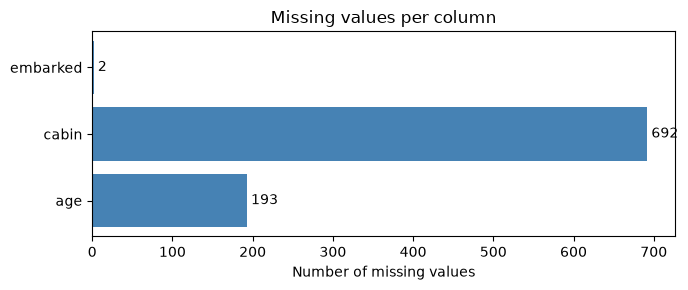

In [17]:
import matplotlib.pyplot as plt

cols = list(missing_counts.keys())
counts = list(missing_counts.values())

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(cols, counts, color="steelblue")
ax.set_xlabel("Number of missing values")
ax.set_title("Missing values per column")
for i, v in enumerate(counts):
    ax.text(v + 5, i, str(v), va="center")
plt.tight_layout()
plt.show()

### 6.2 Decide: the four main strategies

There is no single correct fix. You choose per column, based on *how much* is missing and *what the column means*.

| Strategy | How | When to use it |
|----------|-----|----------------|
| **Drop rows** | `df.dropna(subset=["col"])` | Very few rows affected and the value is essential |
| **Drop the column** | `df.drop(columns=["col"])` | So much is missing that the column is useless (rule of thumb: more than ~60-70%) |
| **Fill with median / mean** | `df["col"].fillna(df["col"].median())` | Numeric columns. **Median** (the middle value) is safer than **mean** (the average) because outliers do not distort it |
| **Fill with mode or a constant** | `df["col"].fillna("Unknown")` | Text/category columns. **Mode** = the most frequent value |

Filling in a replacement value is called **imputation**. Golden rule: never invent precision you do not have. Filling 77% of a column would be inventing data.

### 6.3 Fix: apply the right strategy to each column

- **cabin** (77% missing): dropping the column would be defensible. We instead fill with the constant `"Unknown"`, which keeps the little information we do have ("having a recorded cabin" actually correlates with 1st class). We show the drop-column option too, on a throwaway copy.
- **age** (about 20% missing): fill with the **median** age.
- **embarked** (2 missing): fill with the **mode** (most common port).

In [18]:
# Option we considered but did NOT keep: dropping the cabin column.
demo = messy.copy()
demo = demo.drop(columns=["cabin"])
print("If we dropped cabin, columns would be:", demo.shape[1])

# Our actual choice: fill cabin with the constant "Unknown"
messy["cabin"] = messy["cabin"].fillna("Unknown")
print("Missing in cabin after filling:", messy["cabin"].isna().sum())

If we dropped cabin, columns would be: 11
Missing in cabin after filling: 0


Next, `age`: fill its missing values with the **median**, as decided above. `.median()` skips NaN values automatically, so we can compute it before filling.

In [19]:
# age: fill with the median
median_age = messy["age"].median()
print("Median age:", median_age)
messy["age"] = messy["age"].fillna(median_age)
print("Missing in age after filling:", messy["age"].isna().sum())

Median age: 28.0
Missing in age after filling: 0


Finally `embarked`: only a couple of values are missing, so we fill with the **mode**, the most frequent port.

In [20]:
# embarked: fill with the mode (most frequent value)
mode_embarked = messy["embarked"].mode().iloc[0]   # mode() returns a Series; take the first entry
print("Most common port:", repr(mode_embarked))
messy["embarked"] = messy["embarked"].fillna(mode_embarked)
print("Missing in embarked after filling:", messy["embarked"].isna().sum())

Most common port: 'S'
Missing in embarked after filling: 0


One honest caveat: the median age we just used was computed while three fake ages of 999 were still in the column. The median barely moved, because the median is robust to outliers — that is exactly why we chose it over the mean. In a real project you would hunt for impossible values *before* imputing; we fix the 999s in section 9 and you will see the effect is tiny.

Final check that no column has missing values left (except what we will create on purpose in section 9):

In [21]:
print("Total missing cells:", messy.isna().sum().sum())

Total missing cells: 0


## 7. Remove duplicate rows

A **duplicate row** is a row that is an exact copy of another row. Duplicates inflate counts and averages: if one passenger appears twice, your "number of passengers" is wrong.

Two tools:

- `df.duplicated()` returns True/False per row. By default a row is flagged only from its **second** appearance onward (the first copy is kept as "the original").
- `df.drop_duplicates()` removes the flagged rows.

Both accept a `keep=` option: `keep="first"` (default, keep the first copy), `keep="last"` (keep the last copy), or `keep=False` (flag **all** copies, useful for inspecting them).

In [22]:
print("Duplicate rows found:", messy.duplicated().sum())

# Look at them before deleting - with keep=False we see originals AND copies
messy[messy.duplicated(keep=False)].sort_values("passenger_id").head(6)

Duplicate rows found: 5


,passenger_id,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,Unknown,C
895,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,Unknown,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,Unknown,S
892,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,Unknown,S
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,28.0,1,1,2661,15.2458,Unknown,C
891,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,28.0,1,1,2661,15.2458,Unknown,C


They are exact copies indeed. Remove them with `drop_duplicates()`, keeping the first occurrence of each row.

In [23]:
before = len(messy)
messy = messy.drop_duplicates(keep="first")
messy = messy.reset_index(drop=True)     # renumber rows 0,1,2,... after deleting
print(f"Rows: {before} -> {len(messy)}  (removed {before - len(messy)} duplicates)")

Rows: 896 -> 891  (removed 5 duplicates)


Note the `reset_index(drop=True)` after dropping rows: pandas keeps the old row numbers by default, which leaves gaps. Resetting gives us a tidy 0, 1, 2, ... numbering again. `drop=True` means "throw the old numbering away instead of saving it as a new column".

## 8. Clean inconsistent text

To a computer, `"male"`, `"Male "`, and `" MALE"` are three **different** values. Count them with `value_counts()` and you get a nonsense answer. Let's see the damage first.

In [24]:
print(messy["sex"].value_counts())

sex
male        567
female      312
Male          5
 MALE         5
Female        1
 female       1
Name: count, dtype: int64


### The professional way: vectorized string methods

pandas gives every text column a `.str` toolbox, which applies a string operation to **every value at once**. This is called **vectorization**: one command, all rows, no loop needed.

- `.str.strip()` removes leading/trailing spaces from every value.
- `.str.lower()` lowercases every value.

They chain naturally: `messy["sex"].str.strip().str.lower()`.

In [25]:
messy["sex"] = messy["sex"].str.strip().str.lower()
print(messy["sex"].value_counts())

sex
male      577
female    314
Name: count, dtype: int64


### The same thing with an explicit loop (so you see what vectorization replaces)

Under the hood, vectorization does what this loop does — just much faster and in optimized C code. We apply the loop to `embarked` so you can see the pattern with `.loc` row-by-row. `isinstance(value, str)` checks that the value really is text before we call string methods on it.

In [26]:
for i in messy.index:                      # loop over every row number
    value = messy.loc[i, "embarked"]
    if isinstance(value, str):             # only touch text values
        messy.loc[i, "embarked"] = value.strip().upper()

print(messy["embarked"].value_counts())

embarked
S    646
C    168
Q     77
Name: count, dtype: int64


Both approaches work. **In practice, always prefer the `.str` methods**: they are shorter, faster (on 1 million rows the loop takes minutes, vectorization takes milliseconds), and easier to read. The loop version is still worth knowing — it is your fallback for logic too custom for built-in methods.

### Mapping dictionaries and .replace

Sometimes cleaning is not about spaces but about *standardizing labels*. Say we want full words instead of single letters in `embarked`. A **mapping dictionary** plus `.replace()` does it in one move: every key found in the column is replaced by its value. (Tip: `.replace()` leaves values that are not in the dictionary untouched; the related method `.map()` would turn those into NaN, so `.replace()` is the safer choice for partial mappings.)

In [27]:
port_names = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
messy["embarked"] = messy["embarked"].replace(port_names)
print(messy["embarked"].value_counts())

embarked
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


## 9. Impossible values and outliers

Two related but different problems:

- An **impossible value** breaks the rules of reality: an age of 999, a fare of -1. These are always errors. Delete or repair them.
- An **outlier** is a value that is *unusual* but possibly real: a first-class fare of 512 pounds is enormous, but someone really paid it. Outliers need judgment, not automatic deletion.

### 9.1 Logical rules for impossible values

Write down what *must* be true for each column and check it with a **boolean mask** (a True/False test per row used to select rows):

- age must be between 0 and 100
- fare must be >= 0

In [28]:
bad_age = (messy["age"] < 0) | (messy["age"] > 100)     # | means OR
bad_fare = messy["fare"] < 0

print("Rows breaking the age rule: ", bad_age.sum())
print("Rows breaking the fare rule:", bad_fare.sum())
messy.loc[bad_age | bad_fare, ["passenger_id", "name", "age", "fare"]]

Rows breaking the age rule:  3
Rows breaking the fare rule: 3


,passenger_id,name,age,fare
56,57,"Rugg, Miss. Emily",21.0,-1.000
204,205,"Cohen, Mr. Gurshon ""Gus""",999.0,8.050
393,394,"Newell, Miss. Marjorie",999.0,113.275
398,399,"Pain, Dr. Alfred",999.0,10.500
764,765,"Eklund, Mr. Hans Linus",16.0,-1.000
789,790,"Guggenheim, Mr. Benjamin",46.0,-1.000


There are our injected fakes. The repair: set them to NaN (honest "we do not know"), then impute again with the median, exactly like section 6. Note how we use `.loc` with the mask to overwrite only the guilty cells. Also note: `np.nan` is NumPy's missing-value marker — the same NaN pandas uses.

In [29]:
messy.loc[bad_age, "age"] = np.nan
messy.loc[bad_fare, "fare"] = np.nan

new_median_age = messy["age"].median()
print("Median age without the 999s:", new_median_age, "(before it was 28.0 - barely moved)")

messy["age"] = messy["age"].fillna(new_median_age)
messy["fare"] = messy["fare"].fillna(messy["fare"].median())
print("Missing cells now:", messy.isna().sum().sum())
print("Age range now:", messy["age"].min(), "to", messy["age"].max())

Median age without the 999s: 28.0 (before it was 28.0 - barely moved)
Missing cells now: 0
Age range now: 0.42 to 80.0


### 9.2 Outliers with the IQR method

For values that are *legal but extreme*, the classic detector is the **IQR method**:

- **Q1** = 25th percentile (a quarter of values are below it), **Q3** = 75th percentile.
- **IQR** (interquartile range) = Q3 - Q1, the spread of the "middle half" of the data.
- Anything below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is flagged as an outlier.

A **boxplot** draws exactly this: the box is Q1-to-Q3, the line inside is the median, the whiskers reach the 1.5*IQR fences, and the dots beyond them are the flagged outliers.

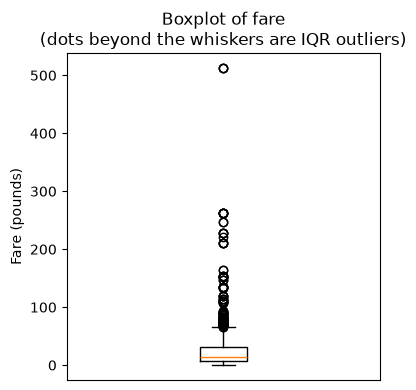

In [30]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.boxplot(messy["fare"])
ax.set_ylabel("Fare (pounds)")
ax.set_xticks([])
ax.set_title("Boxplot of fare\n(dots beyond the whiskers are IQR outliers)")
plt.tight_layout()
plt.show()

The dots above the top whisker are the flagged outliers. Now compute the same fences by hand with `.quantile()` and count exactly how many fares fall outside them.

In [31]:
q1 = messy["fare"].quantile(0.25)
q3 = messy["fare"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = (messy["fare"] < lower_fence) | (messy["fare"] > upper_fence)
print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
print(f"Fences: below {lower_fence:.2f} or above {upper_fence:.2f}")
print("Fare outliers flagged:", outliers.sum())
print("Highest fares:", sorted(messy["fare"].nlargest(3).round(2)))

Q1=7.92  Q3=31.00  IQR=23.07
Fences: below -26.69 or above 65.61
Fare outliers flagged: 115
Highest fares: [512.33, 512.33, 512.33]


### 9.3 Cap, drop, or keep?

Three options for flagged outliers, in order of preference:

| Option | How | When |
|--------|-----|------|
| **Keep** | do nothing | The values are real and meaningful (our case: rich passengers really paid 512 pounds) |
| **Cap** (also called *winsorizing*) | `df["col"].clip(lower=..., upper=...)` | Values are real but would distort a model or average; pull them in to the fence |
| **Drop** | filter the rows out | You have evidence the values are errors |

We demonstrate capping on a **copy** so you see the mechanics, but for our final dataset we **keep** the real fares — deleting rich passengers would bias every later analysis. This is the key lesson: outlier handling is a *decision you justify*, not a reflex.

In [32]:
capped_demo = messy.copy()
capped_demo["fare"] = capped_demo["fare"].clip(lower=lower_fence, upper=upper_fence)
print("Max fare original:", messy["fare"].max())
print("Max fare capped:  ", capped_demo["fare"].max())

Max fare original: 512.3292
Max fare capped:   65.6125


## 10. Loops power-section: every pattern in one place

You have now used loops all over this notebook. This section collects **the four loop patterns every data person needs**, each with tiny standalone examples you can copy into any project. (Standalone means: they do not depend on the Titanic data.)

### Pattern 1: for over a list (or over df.columns)

The workhorse. Loop over any collection and do something with each item.

In [33]:
# Example 1a: loop over a plain list
scores = [7.5, 8.0, 6.1]
for s in scores:
    print("Score:", s)

# Example 1b: loop over columns of a tiny DataFrame
tiny = pd.DataFrame({"a": [1, 2], "b": [3, 4]})
for col in tiny.columns:
    print(col, "sums to", tiny[col].sum())

Score: 7.5
Score: 8.0
Score: 6.1
a sums to 3
b sums to 7


### Pattern 2: for with zip

`zip(list1, list2)` pairs items up: first with first, second with second, ... Perfect when two lists belong together, like column names and the values you want to fill them with.

In [34]:
# Example 2a: walk two lists in parallel
students = ["Anna", "Ben", "Chris"]
grades = [8, 6, 9]
for student, grade in zip(students, grades):
    print(student, "scored", grade)

# Example 2b: pair columns with a chosen fill value for each
columns = ["age", "city"]
fill_values = [0, "Unknown"]
for col, fill in zip(columns, fill_values):
    print(f"Plan: fill missing {col} with {fill!r}")

Anna scored 8
Ben scored 6
Chris scored 9
Plan: fill missing age with 0
Plan: fill missing city with 'Unknown'


### Pattern 3: looping over a dictionary

`dict.items()` gives you key and value together. This is the natural partner of mapping dictionaries (section 8) and of report dictionaries (section 6).

In [35]:
# Example 3a: print a mapping
port_names = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
for code_letter, full_name in port_names.items():
    print(code_letter, "means", full_name)

# Example 3b: build a dict with a loop, then read it back
lengths = {}
for word in ["data", "cleaning", "rocks"]:
    lengths[word] = len(word)
for word, n in lengths.items():
    print(word, "has", n, "letters")

S means Southampton
C means Cherbourg
Q means Queenstown
data has 4 letters
cleaning has 8 letters
rocks has 5 letters


### Pattern 4: list comprehensions

A **list comprehension** is a one-line loop that builds a list: `[expression for item in collection]`. You can add a filter: `[x for x in items if condition]`. It is exactly the build-a-list pattern from section 4, compressed. Use it when the body is a single simple expression; use a normal loop when the logic is longer.

In [36]:
# Example 4a: clean names in one line (compare with the loop in section 4)
raw = [" Name ", "AGE", " City"]
clean = [c.strip().lower() for c in raw]
print(clean)

# Example 4b: with a filter - keep only numeric columns of a DataFrame
tiny = pd.DataFrame({"a": [1, 2], "b": ["x", "y"], "c": [0.5, 1.5]})
numeric_cols = [col for col in tiny.columns if pd.api.types.is_numeric_dtype(tiny[col])]
print("Numeric columns:", numeric_cols)

# Example 4c: squares of even numbers 0..9
print([n * n for n in range(10) if n % 2 == 0])

['name', 'age', 'city']
Numeric columns: ['a', 'c']
[0, 4, 16, 36, 64]


**When to loop and when not to:** if pandas has a vectorized method for the job (`.str.lower()`, `.fillna()`, `.replace()`), use it — it is faster and clearer. Reach for an explicit loop when you orchestrate *many columns* (patterns 1-3) or need custom per-row logic that no built-in covers.

## 11. Final check and saving the result

### 11.1 A reusable quick_report function

Let's package everything we check on a new dataset into one **function** (a named, reusable block of code defined with `def`). Keep this in your toolbox: run it on *any* DataFrame, at the start and at the end of every cleaning job.

In [37]:
def quick_report(df, name="dataset"):
    """Print a compact data-quality report for a DataFrame."""
    print(f"=== Quick report: {name} ===")
    print(f"Rows: {len(df)}   Columns: {df.shape[1]}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print(f"Total missing cells: {df.isna().sum().sum()}")
    print(f"{'column':<14} {'dtype':<10} {'missing':>8} {'unique':>8}")
    print("-" * 44)
    for col in df.columns:
        print(f"{col:<14} {str(df[col].dtype):<10} "
              f"{df[col].isna().sum():>8} {df[col].nunique():>8}")

quick_report(messy, "titanic (cleaned)")

=== Quick report: titanic (cleaned) ===
Rows: 891   Columns: 12
Duplicate rows: 0
Total missing cells: 0
column         dtype       missing   unique
--------------------------------------------
passenger_id   int64             0      891
survived       int64             0        2
pclass         int64             0        3
name           str               0      891
sex            str               0        2
age            float64           0       88
sibsp          int64             0        7
parch          int64             0        7
ticket         str               0      681
fare           float64           0      248
cabin          str               0      148
embarked       str               0        3


### 11.2 Before vs after

How much did we fix? We build a small comparison DataFrame by hand — a nice last demonstration of creating a table from a dictionary. `df` is still the untouched original download; `messy` went through the full wash cycle. (Remember `messy` also received *extra* injected problems that the raw download never had, which is why it started out worse.)

One subtlety: in the "after injection" column the missing-cell count looks *lower* than you might expect, because at that moment the 15 `"unknown"` strings were text, not NaN - they only became countable missing values after `pd.to_numeric` in section 5. Messy data hides its own mess: one more reason to fix dtypes early.

In [38]:
comparison = pd.DataFrame({
    "raw download": [df.shape[0], int(df.isna().sum().sum()), int(df.duplicated().sum())],
    "after injection": [injection_stats["rows"], injection_stats["missing"], injection_stats["duplicates"]],
    "after cleaning": [messy.shape[0], int(messy.isna().sum().sum()), int(messy.duplicated().sum())],
}, index=["rows", "missing cells", "duplicate rows"])
comparison

,raw download,after injection,after cleaning
rows,891,896,891
missing cells,866,872,0
duplicate rows,0,5,0


### 11.3 Save the clean dataset

Last step of every cleaning job: save the result so you (and your teammates) never have to redo the work. We write a CSV into an `outputs/` folder next to the notebook. `os.makedirs(..., exist_ok=True)` creates the folder if needed and does nothing if it already exists. `index=False` keeps pandas from writing the row numbers as an extra column.

In [39]:
import os
os.makedirs("outputs", exist_ok=True)

out_path = os.path.join("outputs", "titanic_clean.csv")
messy.to_csv(out_path, index=False)

print("Saved:", out_path, f"({os.path.getsize(out_path)} bytes)")
pd.read_csv(out_path).head(3)     # read it back to prove it worked

Saved: outputs/titanic_clean.csv (76027 bytes)


,passenger_id,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,Southampton


## Key takeaways

- **Cleaning comes first.** Garbage in, garbage out: no analysis is better than the data behind it.
- **Inspect before you touch anything**: `head()`, `info()`, `describe()`, `shape`, and a missing-values loop.
- **The 6 usual suspects**: bad column names, wrong dtypes, missing values, duplicates, inconsistent text, impossible values/outliers. Check for all six, every time.
- **`pd.to_numeric(errors="coerce")`** turns junk text into NaN so the missing-value tools can handle it.
- **Missing values**: drop rows (few and essential), drop the column (mostly empty), fill median (numeric), fill mode or a constant (categories). Median beats mean because outliers do not distort it.
- **Text cleaning**: `.str.strip().str.lower()` and mapping dictionaries with `.replace()`. Vectorized methods beat row loops for speed and readability.
- **Impossible values are always errors** (fix them); **outliers may be real** (keep, cap, or drop — and justify your choice). The IQR fences are `Q1 - 1.5*IQR` and `Q3 + 1.5*IQR`.
- **Loops are your orchestration tool**: for over columns, zip for parallel lists, dict loops for mappings, list comprehensions for one-line list building.
- **Always use `.loc` when overwriting values**, always set `random_state=42` for reproducibility, and always save your cleaned result.

## Practice exercises

Time to fly solo. Run the next cell to create a small messy DataFrame of webshop orders, then solve the four exercises below it. Try them **before** peeking at the Solutions section.

In [40]:
orders = pd.DataFrame({
    " Customer ": ["anna", "Ben ", " ANNA", "ben", "Carla", "anna", "Ben "],
    "Amount": ["25.0", "40", "unknown", "40", "-5", "25.0", "40"],
    "Country": ["NL", "nl ", "NL", " Nl", "BE", "NL", "nl "],
    "Items": [2, 3, 1, 3, np.nan, 2, 3],
})
orders

,Customer,Amount,Country,Items
0,anna,25.0,NL,2.0
1,Ben,40,nl,3.0
2,ANNA,unknown,NL,1.0
3,ben,40,Nl,3.0
4,Carla,-5,BE,NaN
5,anna,25.0,NL,2.0
6,Ben,40,nl,3.0


**Exercise 1 - Column names.** Clean all column names of `orders` to snake_case (strip spaces, lowercase). Use a loop or a list comprehension.

**Exercise 2 - Types and missing values.** Convert `amount` to a numeric column (the `"unknown"` must become NaN), then fill the missing `amount` values with the column's median and the missing `items` values with 0.

**Exercise 3 - Duplicates and text.** The same order may appear twice: first normalize the text in `customer` and `country` (strip + proper casing), then count and remove duplicate rows. How many rows remain?

**Exercise 4 - Impossible values and a report loop.** An order amount can never be negative. Replace negative amounts with NaN and fill them with the median. Then write a loop over `orders.columns` that prints, for each column: its name, dtype, and number of unique values.

## Solutions

Worked answers below. Your code may look different and still be correct — what matters is the result and the reasoning.

### Solution 1 - Column names

Both the loop and the comprehension work; they are the same idea at different sizes.

In [41]:
# Loop version
new_names = []
for col in orders.columns:
    new_names.append(col.strip().lower())
orders.columns = new_names

# One-line equivalent (would do the same):
# orders.columns = [c.strip().lower() for c in orders.columns]

print(list(orders.columns))

['customer', 'amount', 'country', 'items']


### Solution 2 - Types and missing values

`pd.to_numeric(errors="coerce")` first, then two `fillna` calls with different strategies: median for a money column, the constant 0 for a count column (a missing item count most likely means we simply did not record any).

In [42]:
orders["amount"] = pd.to_numeric(orders["amount"], errors="coerce")
orders["amount"] = orders["amount"].fillna(orders["amount"].median())
orders["items"] = orders["items"].fillna(0)

print(orders.dtypes)
print("Missing cells left:", orders.isna().sum().sum())

customer        str
amount      float64
country         str
items       float64
dtype: object
Missing cells left: 0


### Solution 3 - Duplicates and text

Order matters! If you drop duplicates *before* normalizing text, `"Ben "` and `"ben"` look different and the duplicates survive. Normalize first, then drop. For `customer` we use `.str.title()` to get tidy capitalized names.

In [43]:
orders["customer"] = orders["customer"].str.strip().str.title()
orders["country"] = orders["country"].str.strip().str.upper()

print("Duplicates found:", orders.duplicated().sum())
orders = orders.drop_duplicates().reset_index(drop=True)
print("Rows remaining:", len(orders))
orders

Duplicates found: 3
Rows remaining: 4


,customer,amount,country,items
0,Anna,25.0,NL,2.0
1,Ben,40.0,NL,3.0
2,Anna,32.5,NL,1.0
3,Carla,-5.0,BE,0.0


### Solution 4 - Impossible values and a report loop

Same recipe as section 9: mask with `.loc`, set NaN, refill. Then the report loop — notice it is our friend from section 2, slightly remixed. Once you can write this loop from memory, you own the core skill of this notebook.

In [44]:
negative = orders["amount"] < 0
orders.loc[negative, "amount"] = np.nan
orders["amount"] = orders["amount"].fillna(orders["amount"].median())

for col in orders.columns:
    print(f"{col:<10} dtype={str(orders[col].dtype):<8} unique={orders[col].nunique()}")

orders

customer   dtype=str      unique=3
amount     dtype=float64  unique=3
country    dtype=str      unique=2
items      dtype=float64  unique=4


,customer,amount,country,items
0,Anna,25.0,NL,2.0
1,Ben,40.0,NL,3.0
2,Anna,32.5,NL,1.0
3,Carla,32.5,BE,0.0


---

Well done! You now have a full cleaning workflow and a reusable `quick_report` function. Next up in this module: descriptive statistics, where clean data finally starts answering questions.